In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [3]:
image_path = "../output_video/player_1.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

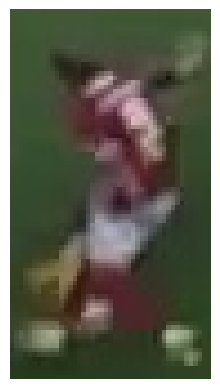

In [4]:
plt.imshow(image)
plt.axis('off')
plt.show()

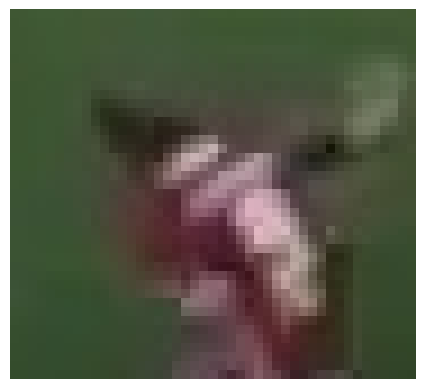

In [5]:
# take uper half of the image
uper_half = image[0: int(image.shape[0]/2), :]
plt.imshow(uper_half)
plt.axis('off')
plt.show()

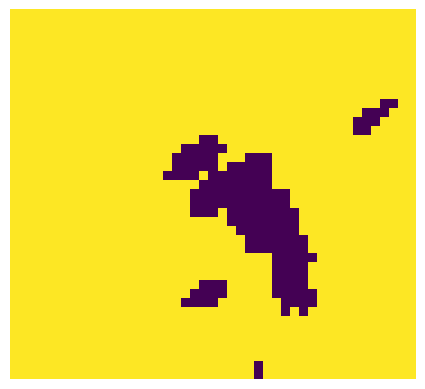

In [10]:
# clustering image into 2 clusters
# reshape the image to 2d array 
image_2d = uper_half.reshape(-1, 3)

# perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# get cluster labels
labels = kmeans.labels_

# reshape labels back to original image shape
clustered_image = labels.reshape(uper_half.shape[0], uper_half.shape[1])

plt.imshow(clustered_image)
plt.axis('off')
plt.show()

In [ ]:
# corners of an image are more likely to contain background
# Extract Corner Pixels
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
print(corner_clusters)
# Find Most Common Corner Cluster
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

[1, 1, 1, 1]
1


In [ ]:
# Identify Player Cluster
player_cluster = 1-non_player_cluster
print(player_cluster)

0


In [ ]:
# Retrieves the dominant RGB color of the player cluster from K-means centroids.
kmeans.cluster_centers_[player_cluster]

array([158.59872611, 130.71974522, 133.81528662])